In [ ]:
from training_functions_2026 import *

bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [ ]:
import tensorflow as tf

# List all available physical devices
print("Physical devices:", tf.config.list_physical_devices())

# List specifically GPU devices
print("GPU devices:", tf.config.list_physical_devices('GPU'))

# Check if TensorFlow can see the GPU
print("Is built with CUDA:", tf.test.is_built_with_cuda())

# Monitor GPU memory growth
print("Memory growth enabled:", tf.config.get_logical_device_configuration(tf.config.list_physical_devices('GPU')[0]))

# See which device is being used for operations
with tf.device('/GPU:0'):
    a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
    b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
    c = tf.matmul(a, b)
    print("Device:", c.device)

Starting Materials Needed:
1. 20x ndpi images
2. downsampled tiff images of the ndpi
3. pre-trained model

In [2]:
################ INPUTS ######################
pth_ndpis = r'\\kittyserverdw\Andre_kit\data\monkey_fetus\Chicken'
# date = '12_31_2024'
date = '10_9_2025'
# new_training_name='Big_Panin_healthy_nPOD'
new_training_name=''
model_name = "monkey"  #"pdac" "panin"  "monkey"  "fallopian_tube" # loaded model name
folderds='1x_python' #'2x'
ds=8 #5 downsampling factor from 10x to 2x
num_tiles_train = 15 #the number of tiles you want to use to train the model
tile_sz=256
#################################################

In [3]:
#STEP 0: create all the paths and folder needed
pthds, output_pixres, tiles_folder, training_tiles_folder, pth_seg_train_tiles, project_train, testing_tiles_folder, pth_seg_test_tiles, project_test, offshoot_trained_model_pth, training_masks_path, outpthmodel, testing_masks_path = pths_folders(pth_ndpis, date, new_training_name,folderds)

In [4]:
nms_twox = sorted([f for f in os.listdir(pthds) if f.endswith('.tif')])
nms_twentyx = sorted([f for f in os.listdir(pth_ndpis) if "".join([f.split(".")[0], '.tif']) in nms_twox and f.endswith('.ndpi')])
# create full file paths
twox_im_pth_list = [os.path.join(pthds, f) for f in nms_twox]
ndpi_im_pth_list= [os.path.join(pth_ndpis, f) for f in nms_twentyx]

In [ ]:
# model = load_selected_models_AF(model_name)
# Load the model and get the paths
# model = load_selected_models_AF(model_name, outpthmodel)
model =  load_selected_models_folder_AF(model_name)

base_model.py (203): output path for model already exists, files may be overwritten: \\kittyserverdw\Andre_kit\data\monkey_fetus\Chicken\stardist_models\_10_9_2025\offshoot_model


Using default values: prob_thresh=0.5, nms_thresh=0.4.
offshoot model path: \\kittyserverdw\Andre_kit\data\monkey_fetus\Chicken\stardist_models\_10_9_2025 

Overriding defaults: Thresholds(prob=0.6883699162882626, nms=0.3) 

Loaded monkey model successfully.


In [ ]:
# GET PIXEL RESOLUTION OF EACH IMAGE NDPI OR SVS FILE
extract_and_save_pixel_sizes(pth_ndpis, output_pixres)

In [ ]:
#STEP 1: SELECT AND CROP 20X IMAGE TILES
#select and crop tiles for training
used_ndpi_list = select_crop_tiles(num_tiles_train, twox_im_pth_list,training_tiles_folder, folderds,output_pixres,ds,tile_sz)
print("training tiles finished")

In [ ]:
num_tiles_test = round(num_tiles_train* 0.3)
#select and crop tiles for testing
select_crop_tiles(num_tiles_test, twox_im_pth_list,testing_tiles_folder, folderds, output_pixres,ds, tile_sz)

In [ ]:
# STEP2: Segment tiles
# saves a .geojson file with segmentation information. If dragged and dropped into QuPath over the tile image, it shows results.

# segment training tiles and save geojson
# segment_save_tiles(training_tiles_folder, model, pth_seg_train_tiles)

# segment testing tiles and save
segment_save_tiles(testing_tiles_folder, model, pth_seg_test_tiles)

In [ ]:
testing_tiles_folder

QuPath Guidance **** IMPORTANT ****
STEPS:
1. create a project on QuPath (select the project folder inside training/testing folder)
2. open the training/testing folder on your computer
3. after project is created on QuPath, drag all the tiff tiles into QuPath
4. drag all the geojson corresponding to the tiff tiles one by one into QuPath
5. edit and revise the contours and save
6. after all annotation is finished: go to stardist git hub > search groovy in files > download this file > drag into QuPath

10_9_2025_lr_0.001_epochs_400_pt_40
760
760
64
64


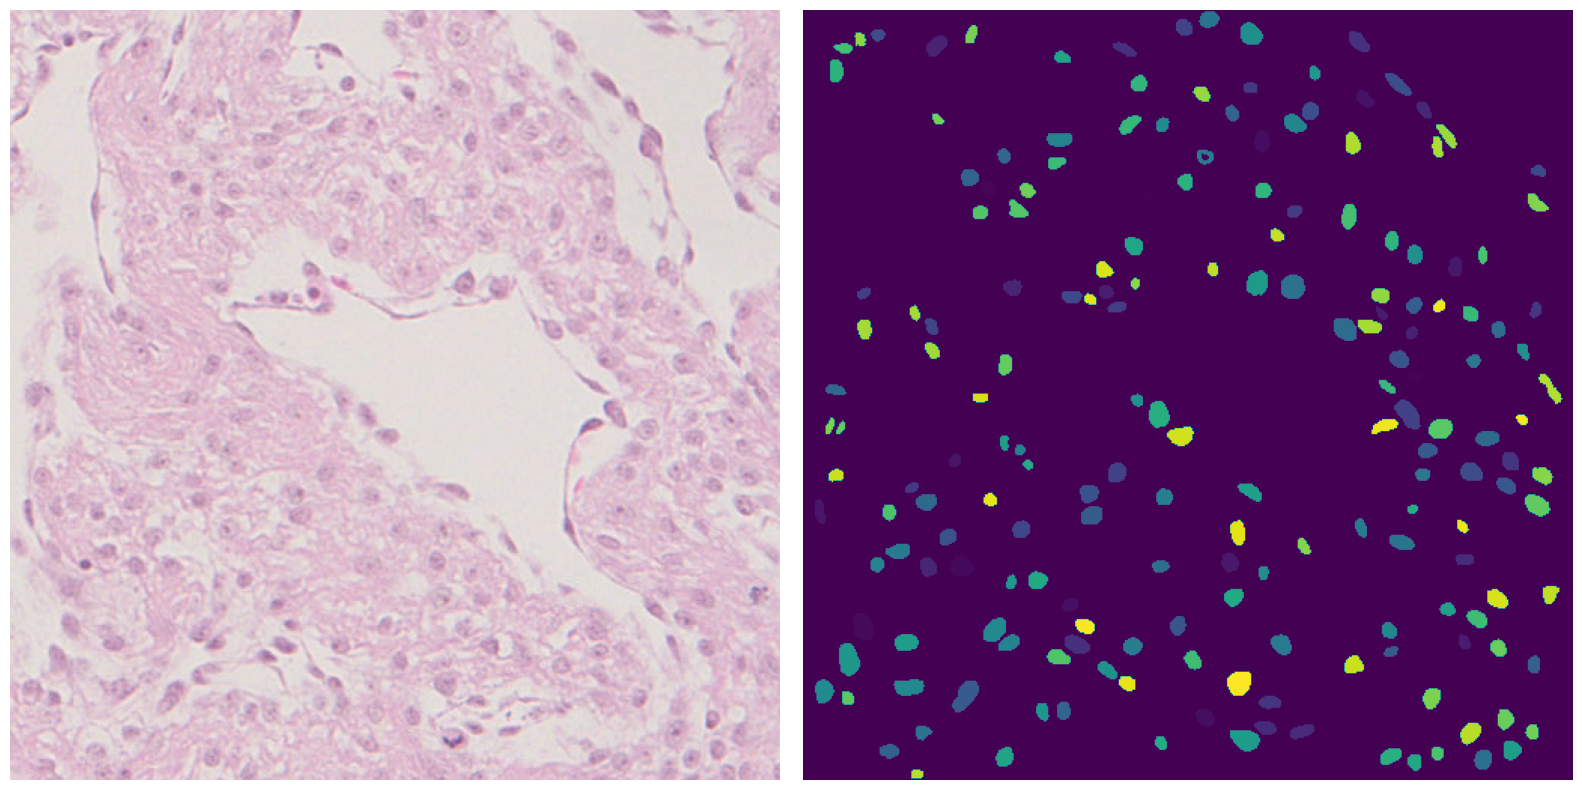

GPU is not available
Training setup finished


In [6]:
# PRE-STEP3: set up training
# tiles_train, HE_train_aug, masks_train_aug, tiles_val, masks_val, pth_log_train = set_up_training(date, new_training_name, outpthmodel, training_tiles_folder, training_masks_path)
# additional_tiles_paths = [
#     r"\\169.254.138.20\Andre\data\Stardist\BIG PANIN model Rita\training_8_10_2024\HEs"#,
#     #r"path/to/additional_tiles_2"
# ]
# additional_masks_paths = [
#     r"\\169.254.138.20\Andre\data\Stardist\BIG PANIN model Rita\training_8_10_2024\masks" #,
#     #r"path/to/additional_masks_2"
# ]
additional_tiles_paths = [
    r"\\10.162.80.16\Andre\data\Stardist\qupath_training_annotations\ground_truth_Catarina_BigPanin_Rita_alligator_cellpose\final\HE"#,
    #r"path/to/additional_tiles_2"
]
additional_masks_paths = [
    r"\\10.162.80.16\Andre\data\Stardist\qupath_training_annotations\ground_truth_Catarina_BigPanin_Rita_alligator_cellpose\final\masks" #,
    #r"path/to/additional_masks_2"
]

# Call the function with additional paths
tiles_train, HE_train_aug, masks_train_aug, tiles_val, masks_val, pth_new_trained_model = set_up_training(
    date, new_training_name, outpthmodel, training_tiles_folder, training_masks_path, additional_tiles_paths, additional_masks_paths
)

In [7]:
# STEP3: TRAIN MODEL BASED ON CURATED ANNOTATED IMAGE TILES
train_model(
    tiles_train=tiles_train,
    model=model,
    offshoot_model_pth=offshoot_trained_model_pth,
    pth_new_trained_model=pth_new_trained_model,
    HE_train_aug=HE_train_aug,
    masks_train_aug=masks_train_aug,
    tiles_val=tiles_val,
    masks_val=masks_val
)
# train_model(
#     tiles_train=tiles_train,
#     model=model,
#     offshoot_model_pth=offshoot_trained_model_pth,
#     pth_new_trained_model=pth_new_trained_model,
#     HE_train_aug=HE_train_aug_crop,
#     masks_train_aug=masks_train_aug_crop,
#     tiles_val=tiles_val,
#     masks_val=masks_val
# )

persistent_dict.py (63): Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
__init__.py (519): Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.


If you want to compute separable approximations, please install it with
pip install scikit-tensor-py3
Epoch 1/400
100/100 [==============================] - 67s 660ms/step - loss: 0.4113 - prob_loss: 0.1671 - dist_loss: 1.2207 - prob_kld: 0.0662 - dist_relevant_mae: 1.2203 - dist_relevant_mse: 3.9927 - dist_dist_iou_metric: 0.6892 - val_loss: 0.4153 - val_prob_loss: 0.1802 - val_dist_loss: 1.1757 - val_prob_kld: 0.0727 - val_dist_relevant_mae: 1.1754 - val_dist_relevant_mse: 3.7606 - val_dist_dist_iou_metric: 0.6935 - lr: 0.0010
Epoch 2/400
100/100 [==============================] - 66s 655ms/step - loss: 0.3845 - prob_loss: 0.1592 - dist_loss: 1.1264 - prob_kld: 0.0575 - dist_relevant_mae: 1.1261 - dist_relevant_mse: 3.4051 - dist_dist_iou_metric: 0.7050 - val_loss: 0.3945 - val_prob_loss: 0.1702 - val_dist_loss: 1.1217 - val_prob_kld: 0.0627 - val_dist_relevant_mae: 1.1213 - val_dist_relevant_mse: 3.4500 - val_dist_dist_iou_metric: 0.7001 - lr: 0.0010
Epoch 3/400
100/100 [===========

NMS threshold = 0.5:  75%|███████▌  | 15/20 [00:30<00:10,  2.04s/it, 0.544 -> 0.722]


Using optimized values: prob_thresh=0.543943, nms_thresh=0.3.
Saving to 'thresholds.json'.
Final training loss: 0.30156567692756653
Final validation loss: 0.36492809653282166


In [ ]:
# STEP4: test model performance 
test_model_performance(pth_new_trained_model, testing_tiles_folder,testing_masks_path)

In [8]:
pth_new_trained_model

'\\\\kittyserverdw\\Andre_kit\\data\\monkey_fetus\\Chicken\\stardist_models\\_10_9_2025\\10_9_2025_lr_0.001_epochs_400_pt_40'

Using default values: prob_thresh=0.5, nms_thresh=0.4.
offshoot model path: \\kittyserverdw\Andre_kit\data\monkey_fetus\Chicken\stardist_models\_10_9_2025\10_9_2025_lr_0.001_epochs_400_pt_40\offshoot_model 

Overriding defaults: Thresholds(prob=0.5439431849275796, nms=0.3) 



100%|██████████| 34/34 [00:06<00:00,  5.18it/s]


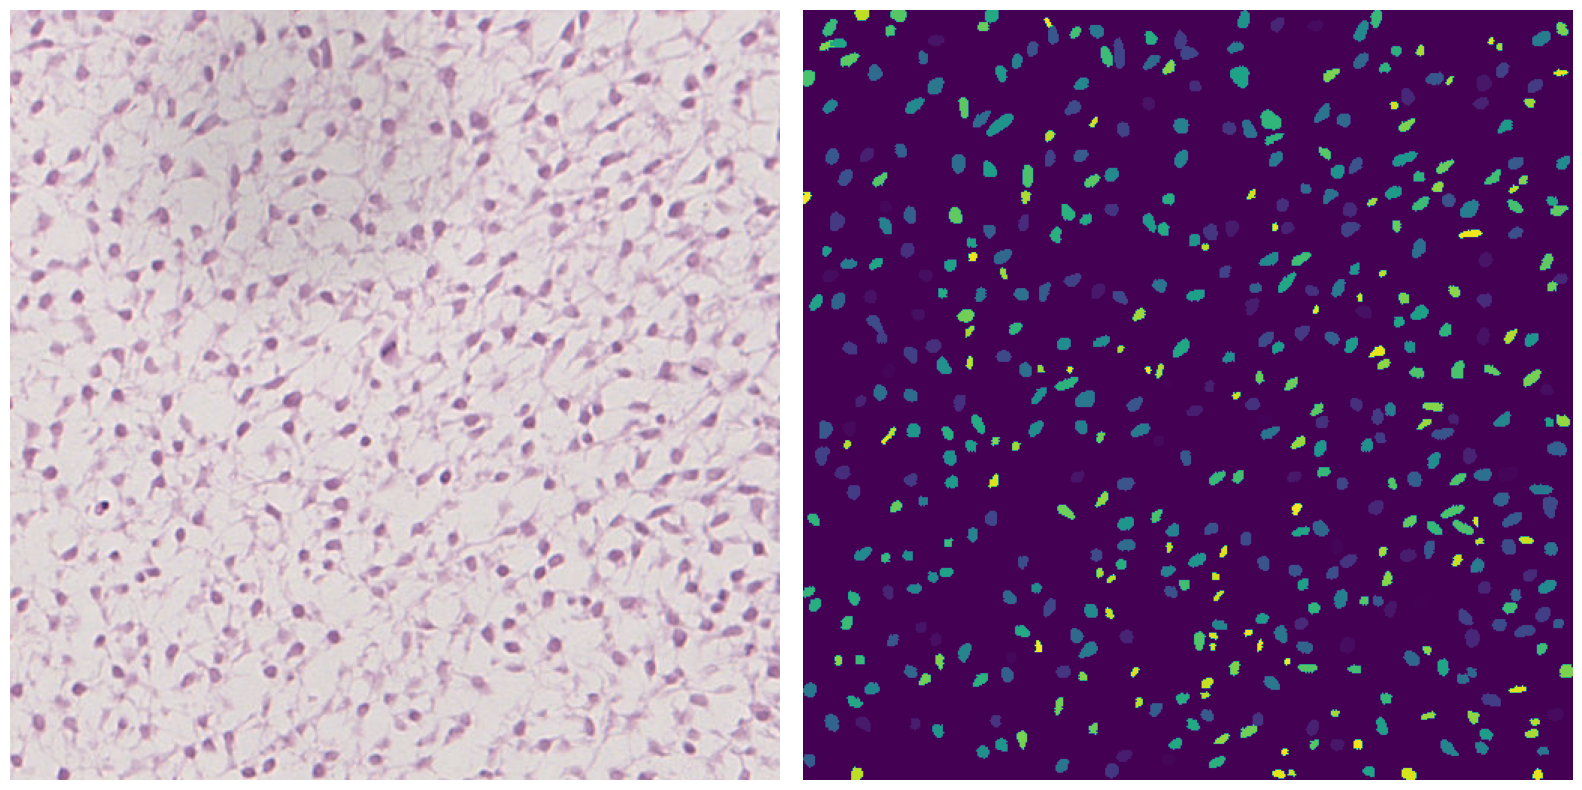

Finished GG_HH_29_0011.geojson
Finished GG_HH_29_0026.geojson
Finished GG_HH_29_0041.geojson
Finished GG_HH_29_0054.geojson
Finished GG_HH_29_0072.geojson
Finished GG_HH_29_0092.geojson
Finished GG_HH_29_0107.geojson
Finished GG_HH_29_0113.geojson
Finished GG_HH_29_0133.geojson
Finished GG_HH_29_0153.geojson
Finished GG_HH_29_0174.geojson
Finished GG_HH_29_0189.geojson
Finished GG_HH_29_0211.geojson
Finished GG_HH_29_0222.geojson
Finished GG_HH_29_0244.geojson
Finished GG_HH_29_0257.geojson
Finished GG_HH_29_0276.geojson
Finished GG_HH_29_0283.geojson
Finished GG_HH_29_0310.geojson
Finished GG_HH_29_0323.geojson
Finished GG_HH_29_0337.geojson
Finished GG_HH_29_0352.geojson
Finished GG_HH_29_0378.geojson
Finished GG_HH_29_0397.geojson
Finished GG_HH_29_0398.geojson
Finished GG_HH_29_0420.geojson
Finished GG_HH_29_0444.geojson
Finished GG_HH_29_0466.geojson
Finished GG_HH_29_0474.geojson
Finished GG_HH_29_0486.geojson
Finished GG_HH_29_0509.geojson
Finished GG_HH_29_0528.geojson
Finished

In [11]:
offshoot_model_pth = create_directory(os.path.join(pth_new_trained_model, 'offshoot_model'))
trained_model = load_model(pth_new_trained_model,offshoot_model_pth)
segment_save_tiles(testing_tiles_folder, trained_model, pth_seg_test_tiles)
